In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

from diffusion_brain_alignment.data.things_monkey_ephys import (
    data_dir,
    area_channels,
    download,
    download_images,
    sample_trials,
    load_stimuli,
    load_brain_response,
)

## Setup

This repo is UV-managed; run the notebook from its environment. For the
first-time DataLad download, `datalad` comes from the environment but
**`git-annex` must be installed as a system command**:

```
brew install git-annex        # macOS
sudo apt install git-annex    # Linux
```

`download()` locates git-annex automatically even if it isn't on the kernel's
PATH (e.g. a conda kernel).

## Download the data

- `download()` pulls the TVSD neural responses (~0.5 GB) via DataLad — public,
  no account.
- `download_images()` pulls the THINGS stimulus images (~5 GB zip on OSF).
  Skipped automatically if the images are already present.

In [3]:
download(monkey="monkeyF")
download_images()

(
    (data_dir / "monkeyF" / "_logs" / "things_imgs.mat").exists(),
    (data_dir / "monkeyF" / "THINGS_normMUA.mat").exists(),
)

(True, True)

## Load responses + stimuli

`sample_trials` picks trials (rows) for a monkey/split; responses and images are
row-aligned to the same trials.

In [4]:
trials = sample_trials(monkey="monkeyF", split="train", n_samples=10)
responses = load_brain_response(trials, roi="V1")
images = load_stimuli(trials)

responses.shape, trials["image_names"][:3], [img is not None for img in images[:3]]

((10, 512),
 ['aardvark/aardvark_01b.jpg',
  'aardvark/aardvark_02s.jpg',
  'aardvark/aardvark_03s.jpg'],
 [True, True, True])

## Stimulus + evoked response

Left: the image the monkey saw. Right: the normMUA it evoked across all 1,024
channels, coloured by area (V1 / V4 / IT). `normMUA` is one value per channel
(no time-course).

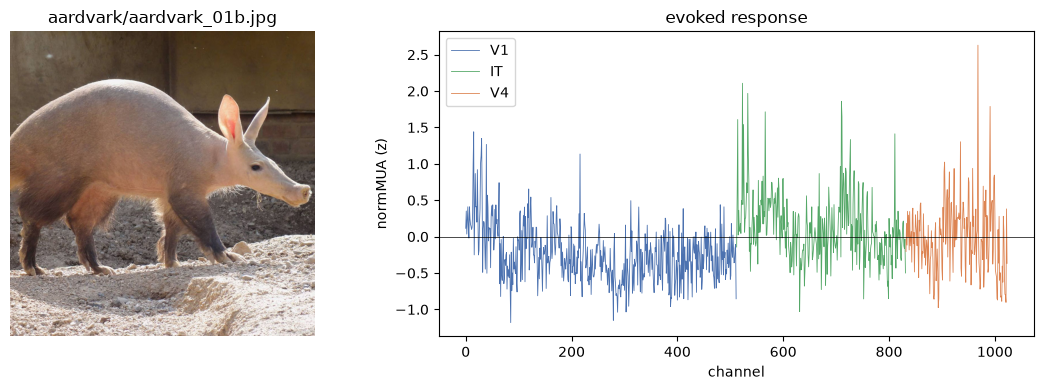

In [5]:
import matplotlib.pyplot as plt

def show_trial(i=0, monkey="monkeyF"):
    trials = sample_trials(monkey=monkey, split="train", n_samples=i + 1)
    resp = load_brain_response(trials)[i]          # (1024,)
    img = load_stimuli(trials)[i]

    fig, (axi, axr) = plt.subplots(1, 2, figsize=(11, 4),
                                   gridspec_kw={"width_ratios": [1, 1.5]})
    if img is not None:
        axi.imshow(img)
    else:
        axi.set_facecolor("#eee"); axi.text(0.5, 0.5, "image not available",
                                             ha="center", va="center")
    axi.axis("off"); axi.set_title(trials["image_names"][i])

    colors = {"V1": "#4C72B0", "V4": "#DD8452", "IT": "#55A868"}
    for area, (lo, hi) in area_channels[monkey].items():
        axr.plot(range(lo, hi), resp[lo:hi], lw=0.6, color=colors[area], label=area)
    axr.axhline(0, color="k", lw=0.5)
    axr.set_xlabel("channel"); axr.set_ylabel("normMUA (z)"); axr.legend()
    axr.set_title("evoked response")
    fig.tight_layout(); plt.show()

show_trial(0)   # aardvark